IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


输出目录: results_xgb_EWS_15min/
数据维度: (59146, 113)
时间范围: 2019-07-01 13:25:00 ~ 2021-06-30 23:55:00
正样本数: 499  (0.84%)

特征准备...
  ✓ market组加入: ['is_official_halt_lag1', 'is_official_halt_lag2']

训练集: 41,816 样本 | 正样本: 107 (0.26%)
验证集: 383 样本  | 正样本: 115 (30.03%)
测试集: 3,759 样本  | 正样本: 244 (6.49%)

  Ablation 实验
baseline_market: 17 features



  baseline_market
    特征数:  17 | PR-AUC: 0.4762 | ROC-AUC: 0.8928 | F1: 0.3628 | Recall: 0.8402
M1_add_cascade: 29 features



  M1_add_cascade
    特征数:  29 | PR-AUC: 0.4477 | ROC-AUC: 0.8708 | F1: 0.3768 | Recall: 0.7582
M2_add_network: 42 features



  M2_add_network
    特征数:  42 | PR-AUC: 0.4059 | ROC-AUC: 0.8452 | F1: 0.2991 | Recall: 0.7336
M3_add_temporal: 77 features


...


  iso_reddit_volume_only
    特征数:  35 | PR-AUC: 0.2025 | ROC-AUC: 0.7484 | F1: 0.2658 | Recall: 0.5164
iso_text_only: 10 features



  iso_text_only
    特征数:  10 | PR-AUC: 0.2003 | ROC-AUC: 0.7908 | F1: 0.2620 | Recall: 0.2582
iso_network_only: 13 features



  iso_network_only
    特征数:  13 | PR-AUC: 0.1553 | ROC-AUC: 0.7428 | F1: 0.2276 | Recall: 0.5246
iso_coordination_only: 15 features



  iso_coordination_only
    特征数:  15 | PR-AUC: 0.2288 | ROC-AUC: 0.7541 | F1: 0.2945 | Recall: 0.5287

  汇总结果
            experiment  n_features  pr_auc  roc_auc     f1  recall
       baseline_market          17  0.4762   0.8928 0.3628  0.8402
        M1_add_cascade          29  0.4477   0.8708 0.3768  0.7582
        M2_add_network          42  0.4059   0.8452 0.2991  0.7336
       M3_add_temporal          77  0.3408   0.8459 0.3173  0.6885
           M4_add_text          87  0.4072   0.8699 0.3787  0.6557
full_with_coordination         102  0.4183   0.8598 0.3775  0.6189
iso_reddit_volume_only          35  0.2025   0.7484 0.2658  0.5164
         iso_text_only          10  0.2003   0.7908 0.2620  0.2582
      iso_network_only          13  0.1553   0.7428 0.2276  0.5246
 iso_coordination_only          15  0.2288   0.7541 0.2945  0.5287

✓ 保存: results_xgb_EWS_15min/ablation_results.csv

  Coordination 边际贡献: +0.0735 (+47.4%)

  最优模型: baseline_market

  最优阈值: 0.60
  PR-AUC : 0.4762  ⭐
  R


  Top 20 SHAP 特征重要性:
returns_std              2.049536
returns_mean             1.151667
returns_z                0.848638
returns_z_lag5min        0.717650
trade_count              0.691185
close                    0.532734
returns                  0.530900
returns_lag5min          0.517538
vwap                     0.484226
low                      0.458813
is_official_halt_lag1    0.446974
low_lag5min              0.400166
high_lag5min             0.387463
open                     0.364713
high                     0.334245
close_lag5min            0.188431
is_official_halt_lag2    0.038303

  每日预测:
            true_events  predicted  max_prob
date                                        
2021-01-28          100        154  0.999886
2021-01-29           15         89  0.999761
2021-02-01           20         84  0.999549
2021-02-02           34        128  0.999910
2021-02-03            9         69  0.999859
2021-02-04            0         19  0.994889
2021-02-05           16        

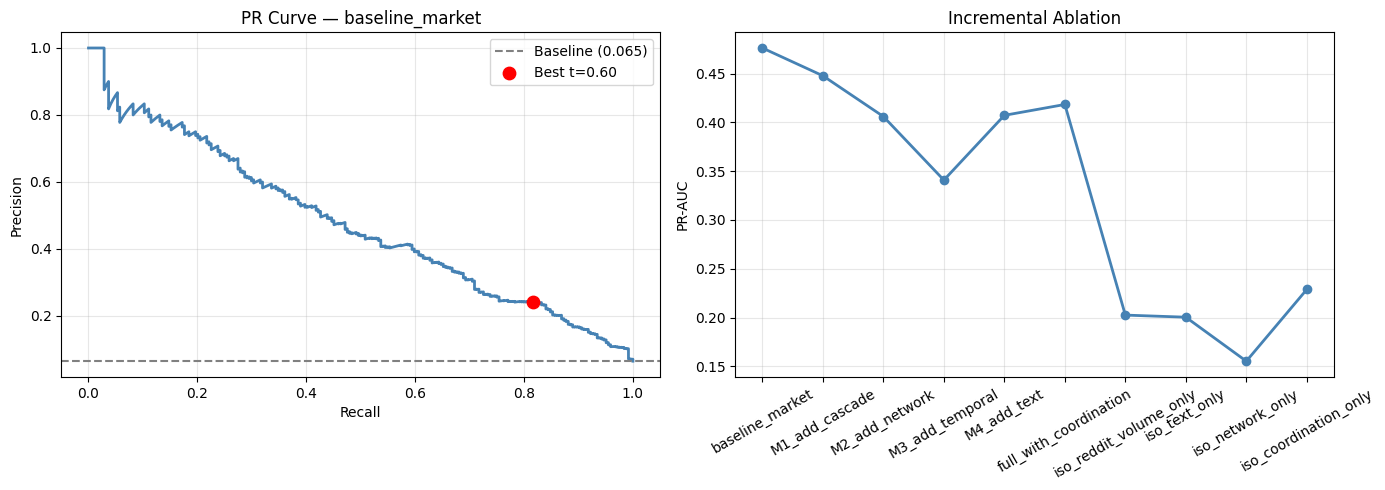


✓ 所有文件已保存到: results_xgb_EWS_15min/


In [1]:
"""
XGBoost 完整版 — 滑动窗口特征
==============================
数据:   data/merged_data_scaled_CLEAN.parquet
标签:   EWS_5min (改这里切换)
训练:   ~ 2021-01-25
验证:   2021-01-26 ~ 01-27  (早停用)
测试:   2021-01-28 ~ 02-28
"""

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score,
                             classification_report, precision_recall_curve)

# ─── 配置 ────────────────────────────────────────────────────────────────────
DATA_FILE   = 'data/merged_data_scaled_CLEAN.parquet'
GROUPS_FILE = 'data/feature_groups_CLEAN.json'
TARGET      = 'EWS_15min'   # ← 改成 EWS_15min / EWS_30min 做robustness

TRAIN_END  = '2021-01-25 23:59:59'
VAL_START  = '2021-01-26 00:00:00'
VAL_END    = '2021-01-27 23:59:59'
TEST_START = '2021-01-28 00:00:00'
TEST_END   = '2021-02-28 23:59:59'

LEAKAGE_FEATURES = [
    'is_episode_t', 'is_luld', 'is_anomaly',
    'is_price_spike', 'is_volume_surge',
    'thread_concentration', 'is_official_halt',
]

# 输出目录（自动创建，按TARGET命名）
import os
OUT_DIR = f'results_xgb_{TARGET}'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'输出目录: {OUT_DIR}/')

XGBOOST_PARAMS = {
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'aucpr',
}

# ─── 1. 加载数据 ─────────────────────────────────────────────────────────────
df = pd.read_parquet(DATA_FILE)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

with open(GROUPS_FILE, 'r') as f:
    feature_groups = json.load(f)

print(f"数据维度: {df.shape}")
print(f"时间范围: {df['timestamp'].min()} ~ {df['timestamp'].max()}")
print(f"正样本数: {int(df[TARGET].sum())}  ({df[TARGET].mean()*100:.2f}%)")

# ─── 2. 特征准备 ───────────────────────────────────────────────────────────────
print("\n特征准备...")

# 官方halt滞后特征
halt_lag = [c for c in ['is_official_halt_lag1', 'is_official_halt_lag2']
            if c in df.columns]
if halt_lag:
    feature_groups['market'] = list(feature_groups.get('market', [])) + halt_lag
    print(f"  ✓ market组加入: {halt_lag}")

# ─── 3. 划分数据集 ───────────────────────────────────────────────────────────
train_mask = df['timestamp'] <= TRAIN_END
val_mask   = (df['timestamp'] >= VAL_START) & (df['timestamp'] <= VAL_END)
test_mask  = (df['timestamp'] >= TEST_START) & (df['timestamp'] <= TEST_END)

y_train = df.loc[train_mask, TARGET]
y_val   = df.loc[val_mask,   TARGET]
y_test  = df.loc[test_mask,  TARGET]

print(f"\n训练集: {train_mask.sum():,} 样本 | 正样本: {int(y_train.sum())} ({y_train.mean()*100:.2f}%)")
print(f"验证集: {val_mask.sum():,} 样本  | 正样本: {int(y_val.sum())} ({y_val.mean()*100:.2f}%)")
print(f"测试集: {test_mask.sum():,} 样本  | 正样本: {int(y_test.sum())} ({y_test.mean()*100:.2f}%)")

# ─── 4. Ablation 实验配置 ────────────────────────────────────────────────────
EXPERIMENTS = {
    # ── 累加式 ablation ──────────────────────────────────────────────────────
    'baseline_market':        ['market'],
    'M1_add_cascade':         ['market', 'cascade'],
    'M2_add_network':         ['market', 'cascade', 'network'],
    'M3_add_temporal':        ['market', 'cascade', 'network', 'temporal'],
    'M4_add_text':            ['market', 'cascade', 'network', 'temporal', 'text'],
    'full_with_coordination': ['market', 'cascade', 'network', 'temporal', 'text',
                               'burstiness', 'user_overlap', 'text_duplication'],

    # ── 隔离式 ablation（baseline_market 同时作为 market-only）──────────────
    'iso_reddit_volume_only': ['temporal'],
    'iso_text_only':          ['text'],
    'iso_network_only':       ['network'],
    'iso_coordination_only':  ['burstiness', 'user_overlap', 'text_duplication'],
}

def get_features(groups_list):
    feats = []
    for g in groups_list:
        feats.extend(feature_groups.get(g, []))
    feats = [f for f in dict.fromkeys(feats) if f in df.columns]
    feats = [f for f in feats if f not in LEAKAGE_FEATURES]
    return feats

# ─── 5. 运行实验 ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  Ablation 实验")
print("="*65)

results = []
models  = {}

spw = (y_train == 0).sum() / y_train.sum()

for exp_name, groups in EXPERIMENTS.items():
    features = get_features(groups)
    print(f'{exp_name}: {len(features)} features')  # ← 加这行
    if not features:
        continue

    X_train = df.loc[train_mask, features].fillna(0)
    X_val   = df.loc[val_mask,   features].fillna(0)
    X_test  = df.loc[test_mask,  features].fillna(0)

    model = XGBClassifier(**XGBOOST_PARAMS, scale_pos_weight=spw)
    model.fit(X_train, y_train, verbose=False)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    pr_auc  = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    recall  = recall_score(y_test, y_pred, zero_division=0)

    print(f"\n  {exp_name}")
    print(f"    特征数: {len(features):>3} | PR-AUC: {pr_auc:.4f} | "
          f"ROC-AUC: {roc_auc:.4f} | F1: {f1:.4f} | Recall: {recall:.4f}")

    results.append({
        'experiment': exp_name,
        'n_features': len(features),
        'pr_auc': pr_auc,
        'roc_auc': roc_auc,
        'f1': f1,
        'recall': recall,
    })
    models[exp_name] = (model, features, y_prob)

# ─── 6. 汇总 ─────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  汇总结果")
print("="*65)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
results_df.to_csv(f'{OUT_DIR}/ablation_results.csv', index=False)
print(f'\n✓ 保存: {OUT_DIR}/ablation_results.csv')

# Coordination 边际贡献
if len(results) >= 2:
    full = results[-1]
    prev = results[-2]
    lift = full['pr_auc'] - prev['pr_auc']
    print(f"\n  Coordination 边际贡献: {lift:+.4f} ({lift/prev['pr_auc']*100:+.1f}%)")

# ─── 7. 最优模型详细评估 ─────────────────────────────────────────────────────
best_exp  = max(results, key=lambda x: x['pr_auc'])['experiment']
model, features, y_prob = models[best_exp]

print(f"\n{'='*65}")
print(f"  最优模型: {best_exp}")
print(f"{'='*65}")

# 最优阈值
thresholds = np.arange(0.02, 0.70, 0.01)
f1s   = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0)
         for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
y_pred = (y_prob >= best_t).astype(int)

print(f"\n  最优阈值: {best_t:.2f}")
print(f"  PR-AUC : {average_precision_score(y_test, y_prob):.4f}  ⭐")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred, digits=3, zero_division=0)}")

# SHAP Top 20
print("  计算 SHAP...")
X_test_df  = df.loc[test_mask, features].fillna(0)
explainer  = shap.TreeExplainer(model)
shap_vals  = explainer.shap_values(X_test_df)
shap_imp   = pd.Series(
    np.abs(shap_vals).mean(axis=0), index=features
).sort_values(ascending=False).head(20)

print(f"\n  Top 20 SHAP 特征重要性:")
print(shap_imp.to_string())
shap_imp.to_csv(f'{OUT_DIR}/shap_importance.csv')

# 每日预测
result_df = df.loc[test_mask, ['timestamp', TARGET]].copy()
result_df['prob'] = y_prob
result_df['pred'] = y_pred
result_df['date'] = result_df['timestamp'].dt.date

daily = result_df.groupby('date').agg(
    true_events=(TARGET, 'sum'),
    predicted=('pred', 'sum'),
    max_prob=('prob', 'max'),
)
print(f"\n  每日预测:")
print(daily.to_string())
daily.to_csv(f'{OUT_DIR}/daily_prediction.csv')

# PR 曲线图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[0].plot(rec, prec, color='steelblue', lw=2)
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline ({y_test.mean():.3f})')
axes[0].scatter(recall_score(y_test, y_pred, zero_division=0),
                precision_score(y_test, y_pred, zero_division=0),
                color='red', s=80, zorder=5, label=f'Best t={best_t:.2f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR Curve — {best_exp}')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(results_df['experiment'], results_df['pr_auc'], 'o-',
             color='steelblue', lw=2)
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('Incremental Ablation')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✓ 所有文件已保存到: {OUT_DIR}/')